# 02 Baseline OCR

This notebook is where I check that the core OCR path is doing something sensible before I worry about cleanup or reporting. The goal is not to make the page look pretty; it is to see whether the crop and line split are at least pointing the model at the right text.

In [ ]:
import sys
from pathlib import Path

cwd = Path.cwd().resolve()
ROOT = cwd if (cwd / 'src').exists() else cwd.parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from PIL import Image
import matplotlib.pyplot as plt

from src.layout import crop_array, extract_main_text_region, segment_lines
from src.ocr_model import TrOCRPrintedBaseline
from src.preprocessing import prepare_line_for_ocr, preprocess_page

In [ ]:
page_paths = sorted((ROOT / 'data' / 'page_images').glob('*.png'))
page_path = page_paths[0]
image = Image.open(page_path).convert('RGB')
views = preprocess_page(image)
crop = extract_main_text_region(views['gray'], views['binary'])
gray_crop = crop_array(views['gray'], crop)
binary_crop = crop_array(views['binary'], crop)
line_arrays = segment_lines(gray_crop, binary_crop)
page_path.name, crop.reason, len(line_arrays)

('buendia_instruccion_page_0001.png', 'fallback_small_crop', 26)

A quick visual check usually tells me more than the first metric run. If the crop is already drifting into side notes here, the OCR result will not mean much.

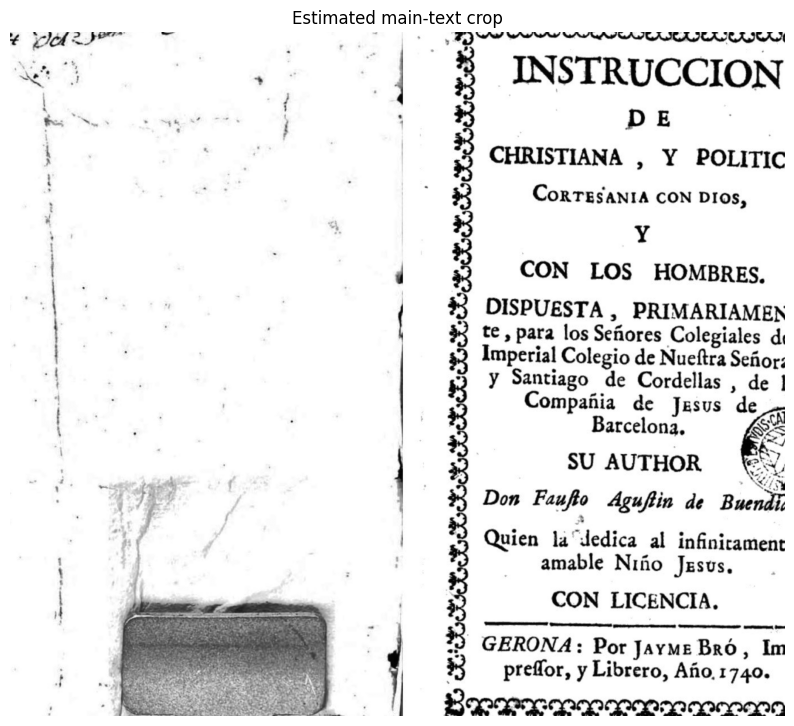

In [ ]:
plt.figure(figsize=(10, 12))
plt.imshow(gray_crop, cmap='gray')
plt.axis('off')
plt.title('Estimated main-text crop');

In [ ]:
model = TrOCRPrintedBaseline()
line_images = [prepare_line_for_ocr(line) for line in line_arrays[:10]]
predictions = model.predict_lines(line_images)
predictions[:5]

Loading weights:   0%|          | 0/478 [00:00<?, ?it/s]

VisionEncoderDecoderModel LOAD REPORT from: microsoft/trocr-base-printed
Key                         | Status  | 
----------------------------+---------+-
encoder.pooler.dense.bias   | MISSING | 
encoder.pooler.dense.weight | MISSING | 

Notes:
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


['4 HRX X 1.1%,',
 '@0.74 3 INSTRUCTION',
 'WWW.WWWW.W.W.M.',
 'UNIMUM P 1 V W',
 'LIAT TAKELL & CHRISTANA, Y POLITIC']